In [ ]:
!pip install torch torchvision tqdm torchview

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 51.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os
import pickle
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm import tqdm
import torch, torch.nn as nn, torch.optim as optim, torch.nn.functional as F, torch.backends.cudnn as cudnn
import torchvision, torchvision.transforms as transforms
import os, argparse, yaml, math, numpy as np
from torch.utils.tensorboard import SummaryWriter
from torchsummary import summary
from datetime import datetime
import torchvision
import dataclasses
import warnings
warnings.simplefilter("ignore")
# from torchview import draw_graph

In [ ]:
#@title config

val_dataset_dir: str = "/content/drive/MyDrive/DL_Project_Data/Data/cifar-10-python/cifar-10-batches-py/test_batch"
dataset_dir: str = "/content/drive/MyDrive/DL_Project_Data/Data/cifar-10-python/cifar-10-batches-py"

batch_size = 256
num_workers = 16 if torch.cuda.is_available() else 4

best_acc = 0  # best test accuracy
start_epoch= 0  # start from epoch 0 or last checkpoint epoch
savename='attempt2-3'

config_dict = {
    'num_blocks' : [4, 4, 3],
    'conv_kernel_sizes' : [3, 3, 3],
    'shortcut_kernel_sizes' : [1, 1, 1],
    'num_channels' : 64,
    'avg_pool_kernel_size' : 8,
    'drop' : 0,
    'squeeze_and_excitation' : 1,
    'grad_clip' : 0.1,
    'max_epochs' : 200,
    'optim' : "sgd",
    'lr_sched' : "CosineAnnealingLR",
    'momentum' : 0.9,
    'lr' : 0.01,
    'weight_decay' : 0.0005,
    'batch_size' : 128,
    'num_workers' : 16,
    'data_augmentation' : 1,
    'data_normalize' : 1,
    'lookahead' : 1,
    'label_smoothing' : 0.1,
    'use_amp' : True,
}

In [ ]:
#@title utils.py

def unpickle(file):
    with open(file, 'rb') as fo:
        data_dict = pickle.load(fo, encoding='bytes')
    return data_dict


def get_device():
    if torch.cuda.is_available():
        device = "cuda"
    elif torch.backends.mps.is_available():
        device = "mps"
    else:
        device = "cpu"
    print("Using device:", device)
    return device

In [ ]:
#@title dataset.py

@dataclasses.dataclass
class DataConfig:
  dataset_dir: str
  val_dataset_dir: str

  add_augmentation: bool = True
  add_jitter: bool = False
  add_normalization: bool = True


class CIFARDataset(Dataset):
    def __init__(self, data, labels, transform=None):
        self.data = data  # shape (N, 3072)
        self.labels = labels  # shape (N,)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img = self.data[idx].reshape(3, 32, 32).transpose(1, 2, 0).astype("uint8")
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label


def get_train_transforms(config: DataConfig):
    train_transforms = [transforms.ToPILImage()]

    if config.add_augmentation:
        train_transforms.extend([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip()
        ])
    if config.add_jitter:
        train_transforms.append(transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1))

    train_transforms.append(transforms.ToTensor())

    if config.add_normalization:
        train_transforms.append(transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)))

    return transforms.Compose(train_transforms)


def get_test_transforms(add_normalization: bool = True):
    test_transforms = [transforms.ToPILImage(), transforms.ToTensor()]

    if add_normalization:
        test_transforms.append(transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)))

    return  transforms.Compose(test_transforms)


def load_train_data(config: DataConfig):
    data_list, labels_list = [], []
    for i in range(1, 6):
        batch_file = os.path.join(config.dataset_dir, f"data_batch_{i}")
        batch = unpickle(batch_file)
        data_list.append(batch[b'data'])
        labels_list.extend(batch[b'labels'])
    X = np.concatenate(data_list, axis=0)
    y = np.array(labels_list)
    return CIFARDataset(X, y, transform=get_train_transforms(config))


def load_test_data(config: DataConfig):
    val_batch = unpickle(config.val_dataset_dir)
    return CIFARDataset(val_batch[b'data'], val_batch[b'labels'], transform=get_test_transforms(config.add_normalization))

In [ ]:
config = DataConfig(
    dataset_dir=dataset_dir,
    val_dataset_dir=val_dataset_dir,
    add_augmentation=config_dict['data_augmentation'],
    add_normalization=config_dict['data_normalize']
)

train_loader = DataLoader(
    load_train_data(config),
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=False
  )
val_loader = DataLoader(
    load_test_data(config),
    batch_size=int(batch_size/4),
    shuffle=False,
    num_workers=num_workers,
    pin_memory=False
  )

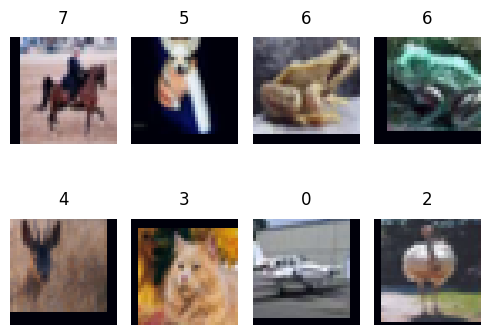

In [ ]:
#@title Visualization
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torchvision

def imshow_with_labels(images, labels, class_names=None, num_images=8):
    """
    Display images with their labels below each image

    Parameters:
    - images: tensor of images
    - labels: tensor of corresponding labels
    - class_names: list of class names (optional)
    - num_images: number of images to display
    """
    # Normalize images back from [-1,1] to [0,1]
    min_val = torch.min(images)
    max_val = torch.max(images)

    # 2. Normalize to [0,1] based on actual range
    if max_val > min_val:  # Avoid division by zero
        images = (images - min_val) / (max_val - min_val)
    else:
        images = torch.zeros_like(images)
    # Convert to numpy
    npimgs = images.numpy()

    # Calculate grid dimensions
    num_images = min(num_images, len(images))
    cols = 4
    rows = (num_images + cols - 1) // cols  # Ceiling division

    # Create figure
    fig, axes = plt.subplots(rows, cols, figsize=(5, 2 * rows))
    fig.subplots_adjust(hspace=0.4)  # Add space between rows

    # Flatten axes array for easier iteration
    axes = axes.flatten() if rows > 1 else [axes]

    for i in range(num_images):
        # Transpose image for display (channels, height, width) -> (height, width, channels)
        img = np.transpose(npimgs[i], (1, 2, 0))
        axes[i].imshow(img)
        axes[i].axis('off')

        # Set label as title below each image
        label = class_names[labels[i].item()] if class_names else str(labels[i].item())
        axes[i].set_title(label, pad=10, loc='center')

    # Hide any unused subplots
    for i in range(num_images, len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()


dataiter = iter(train_loader)
images, labels = next(dataiter)

# class_names = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
imshow_with_labels(images, labels, num_images=8)

In [ ]:
#@title core.py

class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_planes, planes, stride=1, conv_kernel_size=3, shortcut_kernel_size=1, drop=0.4):
        """
        Convolutional Layer kernel size Fi
        Skip connection (shortcut) kernel size Ki
        """
        super(BasicBlock, self).__init__()
        self.drop = drop

        # Pre-activation setup: BN -> GLEU -> Conv2d
        # 1st block
        self.bn1 = nn.BatchNorm2d(in_planes)
        self.conv1 = nn.Conv2d(
            in_channels=in_planes,
            out_channels=planes,
            kernel_size=conv_kernel_size,
            stride=stride,
            padding=int(conv_kernel_size/2),
            bias=False
        )

        # 2nd block:
        self.bn2 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(
            in_channels=planes,
            out_channels=planes,
            kernel_size=conv_kernel_size,
            stride=1,
            padding=int(conv_kernel_size/2),
            bias=False
        )

        # Shortcut --> connect the input back to 2nd block
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.BatchNorm2d(in_planes),
                nn.Conv2d(
                    in_channels=in_planes,
                    out_channels=self.expansion * planes,
                    kernel_size=shortcut_kernel_size,
                    stride=stride,
                    padding=int(shortcut_kernel_size/2),
                    bias=False
                ),

            )

        # Spatial Dropout
        if self.drop:
            self.dropout = nn.Dropout2d(p=self.drop)

    def forward(self, x):
        shortcut = self.shortcut(x)

        # Based on pre-activation setup
        # BN -> GLEU -> Conv2d
        out = self.conv1(F.gelu(self.bn1(x)))
        out = self.conv2(F.gelu(self.bn2(out)))

        # Add shortcut
        out += shortcut

        if self.drop:
            out = self.dropout(out)

        return out


def conv1x1(
    in_channels,
    out_channels,
    stride=1,
    groups=1,
    bias=False
):
    """
    Convolution 1x1 layer.
    Parameters:
    ----------
    in_channels : Number of input channels.
    out_channels : Number of output channels.
    stride : Strides of the convolution.
    groups : Number of groups.
    bias : Whether the layer uses a bias vector.
    """
    return nn.Conv2d(
        in_channels=in_channels,
        out_channels=out_channels,
        kernel_size=1,
        stride=stride,
        groups=groups,
        bias=bias
    )


class SEBlock(nn.Module):
    """
    Squeeze-and-Excitation block from 'Squeeze-and-Excitation Networks,' https://arxiv.org/abs/1709.01507.
    Parameters:
    ----------
    channels : Number of channels.
    reduction : Squeeze reduction value.
    """
    def __init__(
        self,
        channels,
        reduction=16
    ):
        super(SEBlock, self).__init__()
        mid_cannels = channels // reduction

        self.pool = nn.AdaptiveAvgPool2d(output_size=1)
        self.conv1 = conv1x1(
            in_channels=channels,
            out_channels=mid_cannels,
            bias=True
        )
        self.activ = nn.GELU()

        self.conv2 = conv1x1(
            in_channels=mid_cannels,
            out_channels=channels,
            bias=True
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        w = self.pool(x)
        w = self.conv1(w)
        w = self.activ(w)
        w = self.conv2(w)
        w = self.sigmoid(w)
        x = x * w
        return x


class ResNet(nn.Module):
    def __init__(
            self,
            block,
            num_blocks,
            conv_kernel_sizes=None,
            shortcut_kernel_sizes=None,
            num_classes=10,
            num_channels=32,
            avg_pool_kernel_size=4,
            drop=None,
            squeeze_and_excitation=None):
        super(ResNet, self).__init__()
        self.in_planes = num_channels
        # self.avg_pool_kernel_size = avg_pool_kernel_size
        self.avg_pool_kernel_size = int(32 / (2**(len(num_blocks)-1)))

        """
        # of channels Ci
        """
        self.num_channels = num_channels
        self.bn1 = nn.BatchNorm2d(3)
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=self.num_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )


        self.drop = drop
        self.squeeze_and_excitation = squeeze_and_excitation

        if self.squeeze_and_excitation:
            self.seblock = SEBlock(channels=self.num_channels)

        """
        # of Residual Layers N
        # of Residual Blocks Bi
        """
        self.residual_layers = []
        for n in range(len(num_blocks)):
            stride = 1 if n==0 else 2 # stride=1 for first residual layer, and stride=2 for the remaining layers
            conv_kernel_size = conv_kernel_sizes[n] if conv_kernel_sizes else 3 # setting default kernel size of block's convolutional layers
            shortcut_kernel_size = shortcut_kernel_sizes[n] if shortcut_kernel_sizes else 1 # setting default kernel size of block's skip connection (shortcut) layers
            self.residual_layers.append(self._make_layer(
                                                    block,
                                                    self.num_channels*(2**n),
                                                    num_blocks[n],
                                                    stride=stride,
                                                    conv_kernel_size=conv_kernel_size,
                                                    shortcut_kernel_size=shortcut_kernel_size))

        self.residual_layers = nn.ModuleList(self.residual_layers)
        self.linear = nn.Linear(self.num_channels*(2**n)*block.expansion, num_classes)
        """
        Dropout layer
        """
        if self.drop:
            self.dropout = nn.Dropout(self.drop) # Define proportion or neurons to dropout

    def _make_layer(self, block, planes, num_blocks, stride, conv_kernel_size, shortcut_kernel_size):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_planes, planes, stride, conv_kernel_size, shortcut_kernel_size, drop=self.drop))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.conv1(F.gelu(self.bn1(x)))
        # out = F.relu(self.bn1(self.conv1(x)))
        if self.squeeze_and_excitation: out = self.seblock(out)
        for layer in self.residual_layers:
            out = layer(out)
        """
        Average pool kernel size
        """
        out = F.avg_pool2d(out, self.avg_pool_kernel_size)
        out = out.view(out.size(0), -1)
        if self.drop: out = self.dropout(out)
        out = self.linear(out)
        return out

def model_fn(config_dict):
    model =  ResNet(
            block=BasicBlock,
            num_blocks=config_dict['num_blocks'],
            conv_kernel_sizes=config_dict['conv_kernel_sizes'],
            shortcut_kernel_sizes=config_dict['shortcut_kernel_sizes'],
            num_channels=config_dict['num_channels'],
            avg_pool_kernel_size=config_dict['avg_pool_kernel_size'],
            drop=config_dict['drop'],
            squeeze_and_excitation=config_dict['squeeze_and_excitation']
        )

    total_params = 0
    for x in filter(lambda p: p.requires_grad, model.parameters()):
        total_params += np.prod(x.data.numpy().shape)
    return model, total_params

In [ ]:
class EarlyStopping:
    def __init__(self, patience=30, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0
    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                print("Early stopping triggered!")
                return True
        return False

In [ ]:
device = get_device()

model, params = model_fn(config_dict)
model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=config_dict['label_smoothing'])
optimizer = optim.SGD(model.parameters(), lr=config_dict['lr'], momentum=config_dict["momentum"], weight_decay=config_dict["weight_decay"])
scheduler = None
if config_dict["lr_sched"] == 'CosineAnnealingLR': scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)
scaler = torch.cuda.amp.GradScaler() if config_dict.get("use_amp", False) else None
early_stopping = EarlyStopping(patience=30, min_delta=0.001)
if device == 'cuda':
    net = torch.nn.DataParallel(model)
    cudnn.benchmark = True

#extra
metrics_df = pd.DataFrame(columns=['train_loss', 'train_acc', 'val_loss', 'val_acc', 'lr'])
metrics_df.index.name = 'epoch'

Using device: cuda


In [ ]:
import torch
import os

# Define the path where the checkpoint is saved
save_path = os.path.join('/content/drive/MyDrive/DL_Project_Data/', savename)
checkpoint_path = os.path.join(save_path, 'ckpt.pth')

# Function to load the checkpoint
def load_checkpoint(model, checkpoint_path):
    """
    Load the latest model checkpoint.

    Args:
        model: The PyTorch model instance (uninitialized with weights).
        checkpoint_path: Path to the saved checkpoint file.

    Returns:
        model: Model with loaded weights.
        accuracy: Best accuracy from the checkpoint.
        epoch: Epoch at which the checkpoint was saved.
        config: Configuration saved with the checkpoint.
    """
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"No checkpoint found at {checkpoint_path}")

    # Load the checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device)

    # Load the model weights
    model.load_state_dict(checkpoint['model'])

    # Retrieve additional saved information
    best_acc = checkpoint['accuracy']
    epoch = checkpoint['epoch']
    config = checkpoint['config']

    print(f"Loaded checkpoint from epoch {epoch} with accuracy {best_acc}")

    return model, best_acc, epoch, config


model, best_acc, start_epoch, config = load_checkpoint(model, checkpoint_path)

Loaded checkpoint from epoch 120 with accuracy 93.78


In [ ]:
# Training
def train(epoch, config):
    model.train()
    train_loss = 0
    correct = 0
    total = 0
    train_losses = []
    train_acc = []
    train_progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{config['max_epochs']}", leave=False)  # [NEW]

    for batch_idx, (inputs, targets) in enumerate(train_progress):
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        #outputs = model(inputs)
        # loss = criterion(outputs, targets)
        # loss.backward()
        if config.get("use_amp", False):  # [NEW]
            with torch.cuda.amp.autocast():
                outputs = model(inputs)
                loss = criterion(outputs, targets)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()

            if config["grad_clip"]:
                nn.utils.clip_grad_value_(model.parameters(), clip_value=config["grad_clip"])
            optimizer.step()

        train_loss += loss.item()
        train_losses.append(train_loss)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

        train_acc.append(100.*correct/total)
        train_progress.set_postfix(loss=loss.item())
        # print('Batch_idx: %d | Train Loss: %.3f | Train Acc: %.3f%% (%d/%d)'% (batch_idx, train_loss/(batch_idx+1), 100.*correct/total, correct, total))
    metrics_df.loc[epoch] = [np.mean(train_losses), np.mean(train_acc), np.nan, np.nan, optimizer.param_groups[0]['lr']]  # val_loss and val_acc will be added in the test function
    writer.add_scalar('Loss/train_loss', np.mean(train_losses), epoch)
    writer.add_scalar('Accuracy/train_accuracy', np.mean(train_acc), epoch)

# Testing
def test(epoch, config, savename):
    global best_acc
    model.eval()
    test_loss = 0
    test_losses = []
    test_acc = []
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_idx, (inputs, targets) in enumerate(val_loader):
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            test_loss += loss.item()
            test_losses.append(test_loss)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            test_acc.append(100.*correct/total)
            # print('Batch_idx: %d | Test Loss: %.3f | Test Acc: %.3f%% (%d/%d)'% ( batch_idx, test_loss/(batch_idx+1), 100.*correct/total, correct, total))
        writer.add_scalar('Loss/test_loss', np.mean(test_losses), epoch)
        writer.add_scalar('Accuracy/test_accuracy', np.mean(test_acc), epoch)

    save_path = os.path.join('/content/drive/MyDrive/DL_Project_Data/', savename)
    # Save checkpoint.
    acc = 100.*correct/total
    if acc > best_acc:
        print('Model saved at best validation accuracy accuracy :', acc)
        state = {
            'model': model.state_dict(),
            'accuracy': acc,
            'epoch': epoch,
            'config': config
        }
        if not os.path.isdir(save_path):
            os.mkdir(save_path)
        torch.save(state, os.path.join('/content/drive/MyDrive/DL_Project_Data/', savename, 'ckpt.pth'))
        best_acc = acc
    metrics_df.loc[epoch, ['val_loss', 'val_acc']] = [np.mean(test_losses), np.mean(test_acc)]
    return (test_loss / len(val_loader)), int(np.mean(test_acc))

In [ ]:
print(f"Using device: {device}")
print(f"Model on GPU: {next(model.parameters()).is_cuda}")
print(f"Total Parameters: {params}")


exp = savename + datetime.now().strftime("%Y%m%d_%H%M%S")

writer = SummaryWriter(os.path.join('/content/drive/MyDrive/DL_Project_Data/summaries/', exp))
for epoch in range(start_epoch, config_dict["max_epochs"]):
    train(epoch, config_dict)
    val_loss, val_acc = test(epoch, config_dict, savename)
    print(f"Epoch {epoch+1}/{config_dict['max_epochs']} Val - Loss: {val_loss:.4f} | Accuracy: {val_acc:.4f}")
    scheduler.step()
    # if early_stopping(val_loss):
    #     break
writer.close()
print("Training complete.")
print(f"Best Validation Accuracy: {best_acc:.2f}%")
metrics_df.to_csv(f'/content/drive/MyDrive/DL_Project_Data/{savename}/training_metrics.csv', index=True)

Using device: cuda
Model on GPU: True
Total Parameters: 4696852


Epoch 121/200 Val - Loss: 0.6616 | Accuracy: 93.0000


Epoch 122/200 Val - Loss: 0.6634 | Accuracy: 93.0000


Epoch 123/200 Val - Loss: 0.6624 | Accuracy: 93.0000


Epoch 124/200 Val - Loss: 0.6636 | Accuracy: 94.0000


Epoch 125/200 Val - Loss: 0.6625 | Accuracy: 93.0000


Epoch 126/200:   1%|          | 1/196 [00:02<09:35,  2.95s/it, loss=0.502]

In [ ]:
#print model grapgh here and save that at "save_path+'img.jps' path"
model_graph = draw_graph(model, input_size=(1, 3, 32, 32), expand_nested=True)
plt.figure(figsize=(20, 20))
plt.imshow(model_graph.visual_graph)
plt.axis('off')
plt.show()
image_path = os.path.join('/content/drive/MyDrive/DL_Project_Data/'+exp, 'model_graph.jpg')
model_graph.visual_graph.savefig(image_path)


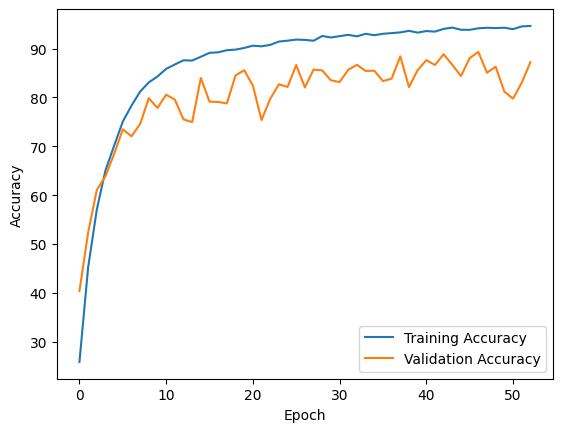

In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.plot(metrics_df.index, metrics_df['train_acc'], label='Training Accuracy')
plt.plot(metrics_df.index, metrics_df['val_acc'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
# ... (similar code for loss) ...

# Plot learning rate
# ... (similar code for learning rate) ...